#**Capstone project: Can ML Outperform Market-Neutral Trading in Structural Breaks?**

**Note:**

It's always a good practise to "restart the session", whenever changes are made to github repository


##**Step 1:** GitHub setup

1) Clone/Update the projects github repository

In [1]:
# Use for the first time to clone the github repo or when the repo is updated
%rm -rf /content/MarketNeutral_Trading/
%cd /content
!git clone https://github.com/WQU-Capstone-11205/MarketNeutral_Trading.git
%cd /content/MarketNeutral_Trading

/content
Cloning into 'MarketNeutral_Trading'...
remote: Enumerating objects: 650, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 650 (delta 54), reused 4 (delta 4), pack-reused 556 (from 1)
Receiving objects: 100% (650/650), 220.82 KiB | 1.54 MiB/s, done.
Resolving deltas: 100% (357/357), done.
/content/MarketNeutral_Trading


2) Add the project's github repository's path to the system path

In [2]:
import sys
sys.path.append('/content/MarketNeutral_Trading')

3) Install projects required packages

In [3]:
!pip install -r requirements.txt

In [4]:
import warnings
warnings.filterwarnings('ignore')

##**Step 2:** Data loading

Load data and convert to distance spread

In [5]:
from data_loading.distance_spread import distance_spread
from util.split_time_series import split_time_series

tickers = ["KO", "PEP"]
spread = distance_spread(tickers, start_date="2005-01-01", end_date="2025-01-01")
train_spread, test_spread = split_time_series(spread)

[*********************100%***********************]  2 of 2 completed


##**Step 3:** Hyperparameter tuning of BOCPD+VAE+RL pipeline

Tune hyper-parameter for BOCPD+VAE+RL pipeline.

In [6]:
bocpd_space = {
    "hazard": [50],
    "mu": [0],
    "kappa": [0.1], #10.0
    "alpha": [1.0], #10.0
    "beta": [0.1] #10.0
}

vae_space = {
    "input_dim": [3],
    "latent_dim": [16],
    "hidden_dim": [256],
    "lr": [1e-3],
    "vae_seq_len": [1], #, 5, 15, 25
    "kl_wt": [0.01]
}

rl_space = {
    "state_dim": [16],
    "action_dim": [1],
    "hidden_dim": [256], #
    "lr": [1e-5]
}

joint_space = {
    "state_window": [25], #50
    "base_action_sigma": [0.01],#0.3
    "wt_multplier": [1,8], #1.5
    "buffer_size_updates": [64], #256
    "sample_batch_size": [16] #128
}

from tuning.bocpd_vae_rl_tuner import BOCPD_VAE_RL_Tuner

bocpd_vae_rl_tuner = BOCPD_VAE_RL_Tuner(bocpd_space, vae_space, rl_space, joint_space)

#bocpd_vae_rl_tuner.tune(train_spread)
bocpd_params, vae_params, rl_params, joint_params = bocpd_vae_rl_tuner.best_params

print(f'bocpd_params = {bocpd_params}')
print(f'vae_params = {vae_params}')
print(f'rl_params = {rl_params}')
print(f'joint_params = {joint_params}')


bocpd_params = {'hazard': 50, 'mu': 0, 'kappa': 0.1, 'alpha': 1.0, 'beta': 0.1}
vae_params = {'input_dim': 3, 'latent_dim': 16, 'hidden_dim': 256, 'lr': 0.001, 'vae_seq_len': 1, 'kl_wt': 0.01}
rl_params = {'state_dim': 16, 'action_dim': 1, 'hidden_dim': 256, 'lr': 1e-05}
joint_params = {'state_window': 25, 'base_action_sigma': 0.01, 'wt_multplier': 1.8, 'buffer_size_updates': 64, 'sample_batch_size': 16}


##**Step 4:** Training of BOCPD+VAE+RL pipeline

In [16]:
from train.train_loop_rl import train_loop_rl

train_loop_rl(train_spread, bocpd_params, vae_params, rl_params, joint_params, num_epochs=25)

100%|██████████| 3522/3522 [00:49<00:00, 71.05it/s]


Epoch 000 | recon loss = 0.0429 | kl loss = 0.6094 | policy loss = -0.0004
Sharpe =15.586
Saved all models + optimizers
Saved best models at epoch 000 (Sharpe=15.586)


100%|██████████| 3522/3522 [00:52<00:00, 66.92it/s]


Epoch 001 | recon loss = 0.0086 | kl loss = 0.5712 | policy loss = -0.0002
Sharpe =5.670


100%|██████████| 3522/3522 [00:54<00:00, 64.94it/s]


...

Epoch 022 | recon loss = 0.0020 | kl loss = 0.3507 | policy loss = 0.0000
Sharpe =11.323


100%|██████████| 3522/3522 [01:43<00:00, 33.96it/s]


Epoch 023 | recon loss = 0.0020 | kl loss = 0.3488 | policy loss = -0.0000
Sharpe =13.908


100%|██████████| 3522/3522 [01:45<00:00, 33.45it/s]


Epoch 024 | recon loss = 0.0019 | kl loss = 0.3477 | policy loss = -0.0000
Sharpe =12.021
Training complete.


##**Step 5:** Testing of BOCPD+VAE+RL pipeline:

In [17]:
from backtest.evaluate_loop_rl import evaluate_loop_rl

test_metrics = evaluate_loop_rl(test_spread, bocpd_params, vae_params, rl_params, joint_params)

Loaded models/opts


100%|██████████| 1509/1509 [00:03<00:00, 381.22it/s]

Evaluation complete.


##**Step 6:** Test metrics BOCPD+VAE+RL pipeline:

In [18]:
import numpy as np
from util.metrics import sharpe_ratio, compute_max_drawdown, sortino_ratio, annual_volatility, alpha_beta

print("Test metrics:")
print(f"Cummulative profit and loss             : {test_metrics['pnl'][-1]:.6f}")
print(f"Sharpe ratio (RL Profit and Loss)       : {sharpe_ratio(np.diff(test_metrics['pnl'])):.6f}")
print(f"Sharpe ratio (Buy and Hold)             : {sharpe_ratio(np.diff(test_spread)):.6f}")
print(f"Sortino ratio (RL)                      : {sortino_ratio(np.diff(test_metrics['pnl'])):.6f}")
print(f"Sortino ratio (Buy and Hold)            : {sortino_ratio(np.diff(test_spread)):.6f}")
print(f"Max drawdown (RL Profit and Loss)       : {compute_max_drawdown(test_metrics['pnl']):.6f}")
print(f"Max drawdown (Buy and Hold)             : {compute_max_drawdown(test_spread):.6f}")
print(f"Annual Volatility (RL Profit and Loss)  : {annual_volatility(test_metrics['pnl']):.6f}")
print(f"Annual Volatility (Buy and Hold)        : {annual_volatility(test_spread):.6f}")
alpha, beta = alpha_beta(test_metrics['pnl'], test_spread)
print(f"Alpha Beta (RL Profit and Loss)         : alpha = {alpha:.6f} , beta = {beta:.6f}")

Test metrics:
Cummulative profit and loss             : 1.657562
Sharpe ratio (RL Profit and Loss)       : 0.298909
Sharpe ratio (Buy and Hold)             : -0.005051
Sortino ratio (RL)                      : 0.335656
Sortino ratio (Buy and Hold)            : -0.007095
Max drawdown (RL Profit and Loss)       : 0.337512
Max drawdown (Buy and Hold)             : 4.101385
Annual Volatility (RL Profit and Loss)  : 3.489291
Annual Volatility (Buy and Hold)        : 59.523597
Alpha Beta (RL Profit and Loss)         : alpha = 314.403484 , beta = 0.002053


##**Step 7:** Plots for BOCPD+VAE+RL pipeline
##7.1) **Original vs Reconstructed Spread:**

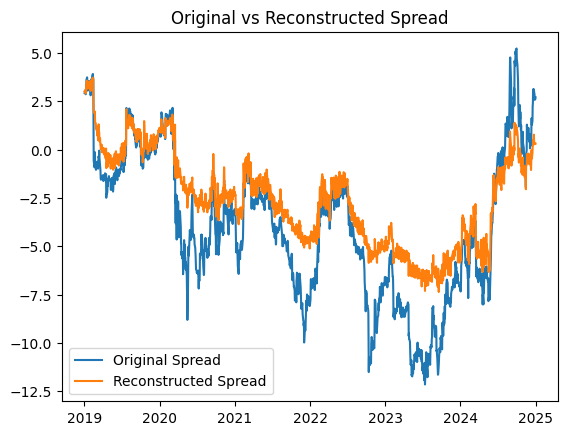

In [19]:
import matplotlib.pyplot as plt

plt.plot(test_spread.index, test_spread, label="Original Spread")
plt.plot(test_spread.index, test_metrics['recons'], label="Reconstructed Spread")
plt.legend();
plt.title("Original vs Reconstructed Spread")
plt.show()

## 7.2) **Drawdown for PnL and Buy & Hold:**

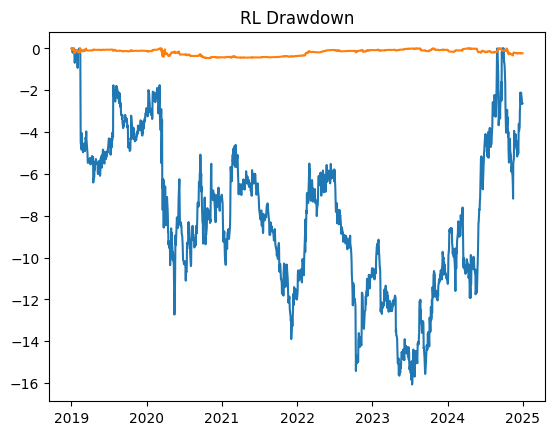

In [20]:
sz = len(test_spread)
cum_pnl_rl = test_metrics['pnl']
rolling_max_rl = np.maximum.accumulate(cum_pnl_rl)
drawdown_rl = cum_pnl_rl - rolling_max_rl
cum_pnl_bh = test_spread
rolling_max_bh = np.maximum.accumulate(cum_pnl_bh)
drawdown_bh = cum_pnl_bh - rolling_max_bh
plt.plot(test_spread.index[:sz-1],drawdown_bh[:sz-1], label="Buy&Hold")
plt.plot(test_spread.index[:sz-1], drawdown_rl, label="RL")
plt.title("RL Drawdown")
plt.show()


## 7.3) **Change Probability over time plot for BOCPD+VAE+RL pipeline:**

np.sum(change_probs > 0.5) = 63
Total len of change_probs = 1509


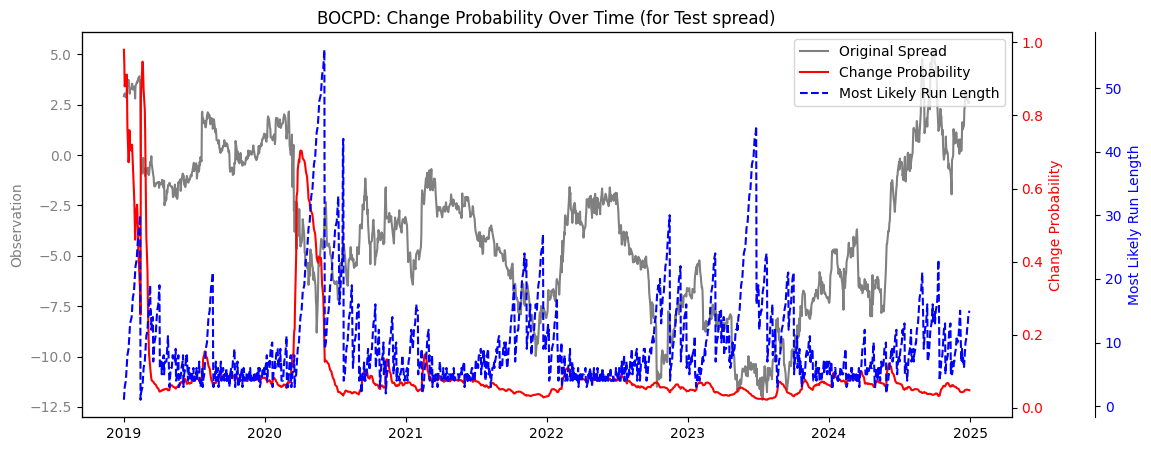

In [21]:
from plots.bocpd import plot_rt_change_probs

plot_rt_change_probs(test_spread, test_metrics['rt_mle'], test_metrics['change_probs'])